# Stage 1 — Data Exploration & Baseline Pipeline

**Goal:** Understand the airfoil CFD dataset, build a normalised `AirfoilDataset`, and verify
the end-to-end training pipeline with a quick overfit sanity-check before we plug in the FNO.

**Data format (per `.npz` file)**
```
array 'a'  shape (6, 128, 128)
  channel 0 — inlet_x   : freestream x-velocity (uniform)
  channel 1 — inlet_y   : freestream y-velocity (uniform)
  channel 2 — geometry  : airfoil mask  (1 inside, 0 outside)
  channel 3 — pressure  : CFD pressure field
  channel 4 — u         : CFD x-velocity field
  channel 5 — v         : CFD y-velocity field
```
Inputs → channels 0-2 &nbsp;&nbsp; Outputs → channels 3-5

In [1]:
# ── shared imports used by every section ──────────────────────────────────────
import os
import glob
import random
import warnings

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── device detection (works on MPS / CUDA / CPU unchanged) ───────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── channel metadata ─────────────────────────────────────────────────────────
INPUT_CHANNELS  = ["inlet_x", "inlet_y", "geometry"]
OUTPUT_CHANNELS = ["pressure", "u", "v"]
ALL_CHANNELS    = INPUT_CHANNELS + OUTPUT_CHANNELS   # display order

# ── project root (notebook lives here) ───────────────────────────────────────
ROOT = os.path.dirname(os.path.abspath("__file__"))  # works in both .py and .ipynb
print(f"Project root : {ROOT}")

Using device: mps
Project root : /Users/idhantsingh/Desktop/aerofno


---
## Section 1 — Load & Inspect

Scans every sub-directory under `./data/` for `.npz` files, loads one sample,
and reports shapes, value ranges, and any NaN / Inf anomalies.

> **No data yet?**  If the `./data/train/` folder is empty the cell below auto-generates
> a small synthetic dataset so every downstream cell still runs correctly.

In [3]:
# ── 1a. locate all .npz files ─────────────────────────────────────────────────
DATA_DIR = os.path.join(ROOT, "data", "train")
os.makedirs(DATA_DIR, exist_ok=True)

npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.npz"), recursive=True))
# also look one level up in case user placed files directly under ./data/
if not npz_files:
    npz_files = sorted(glob.glob(os.path.join(ROOT, "data", "*.npz")))

print(f"Found {len(npz_files)} .npz file(s) under: {DATA_DIR}")

Found 6400 .npz file(s) under: /Users/idhantsingh/Desktop/aerofno/data/train


In [4]:
# ── 1b. synthetic data generator (runs only when no real data is found) ───────

def _make_synthetic_sample(idx: int, rng: np.random.Generator) -> np.ndarray:
    """
    Return a (6, 128, 128) synthetic airfoil simulation sample.

    Closely mirrors the real Deep-Flow-Prediction data format:
      - inlet channels are constant freestream velocity fields
      - geometry is a fixed NACA-style airfoil mask (same across samples)
      - output flow fields are smooth and physics-inspired

    Geometry is kept fixed across all samples so Section 6 overfit sanity
    check can converge: flow fields then vary only with inlet angle, and the
    positional encoding in MiniCNN resolves remaining spatial ambiguities.
    """
    H, W = 128, 128
    xs = np.linspace(0, 1, W)
    ys = np.linspace(-0.5, 0.5, H)
    XX, YY = np.meshgrid(xs, ys)

    # --- freestream (random angle, random speed) -----------------------------
    angle   = rng.uniform(-np.pi / 8, np.pi / 8)
    v_mag   = rng.uniform(10, 80)
    vx      = v_mag * np.cos(angle)
    vy      = v_mag * np.sin(angle)

    inlet_x = np.full((H, W), vx, dtype=np.float32)   # channel 0
    inlet_y = np.full((H, W), vy, dtype=np.float32)   # channel 1

    # --- fixed NACA-4-digit-style airfoil geometry ---------------------------
    chord, thick, cx, cy = 0.35, 0.12, 0.40, 0.0
    x_norm  = np.clip((XX - (cx - chord / 2)) / chord, 0, 1)
    half_t  = 5 * thick * chord * (
        0.2969 * np.sqrt(x_norm) - 0.1260 * x_norm
        - 0.3516 * x_norm**2 + 0.2843 * x_norm**3 - 0.1015 * x_norm**4
    )
    mask     = (XX >= cx - chord/2) & (XX <= cx + chord/2) & (np.abs(YY - cy) < half_t)
    geometry = mask.astype(np.float32)                 # channel 2
    exterior = 1.0 - geometry

    # --- synthetic flow fields -----------------------------------------------
    dist = np.sqrt((XX - cx)**2 + (YY - cy)**2) + 1e-6
    wake = np.exp(-((XX - (cx + chord / 2))**2) / (0.1**2) - (YY - cy)**2 / (0.05**2))

    ca = np.cos(angle); sa = np.sin(angle)

    # pressure: Gaussian bump near stagnation, scaled by v_mag^2 (physics-like)
    pressure_raw = (0.5 * 1.225 * v_mag**2) * (1.0 / (1 + 10 * dist**2))
    pressure_raw -= pressure_raw.mean()
    pressure_raw[mask] = 0.0
    pressure = pressure_raw.astype(np.float32)         # channel 3

    # u, v: smooth perturbation fields, no random noise
    u = (vx * exterior * (1 + 0.3 * wake)).astype(np.float32)   # channel 4
    v = (vy * exterior + vx * 0.1 * (YY - cy) / (dist + 0.1)).astype(np.float32)
    u[mask] = 0.0; v[mask] = 0.0                               # channel 5

    return np.stack([inlet_x, inlet_y, geometry, pressure, u, v], axis=0)  # (6,128,128)


N_SYNTHETIC = 200   # samples to generate when real data is absent

if not npz_files:
    print(f"No real data found — generating {N_SYNTHETIC} synthetic samples in {DATA_DIR}")
    rng = np.random.default_rng(SEED)
    for i in tqdm(range(N_SYNTHETIC), desc="Generating synthetic data"):
        arr = _make_synthetic_sample(i, rng)
        out_path = os.path.join(DATA_DIR, f"synth_{i:04d}.npz")
        np.savez_compressed(out_path, a=arr)
    npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))
    print(f"Generated {len(npz_files)} synthetic samples.")
else:
    print("Real data found — skipping synthetic generation.")



Real data found — skipping synthetic generation.


In [5]:
# ── 1c. inspect one sample ────────────────────────────────────────────────────
sample_path = npz_files[0]
sample_npz  = np.load(sample_path)
sample      = sample_npz["a"]          # shape (6, 128, 128)

print(f"Total samples  : {len(npz_files)}")
print(f"Sample file    : {os.path.basename(sample_path)}")
print(f"Array shape    : {sample.shape}  (channels, H, W)")
print(f"Array dtype    : {sample.dtype}")
print()
print(f"{'Channel':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 56)
for i, name in enumerate(ALL_CHANNELS):
    ch = sample[i]
    print(f"{name:<12} {ch.min():>10.4f} {ch.max():>10.4f} {ch.mean():>10.4f} {ch.std():>10.4f}")

# NaN / Inf check
print()
has_nan = np.isnan(sample).any()
has_inf = np.isinf(sample).any()
print(f"NaN values present : {has_nan}")
print(f"Inf values present : {has_inf}")
if has_nan or has_inf:
    warnings.warn("⚠ Data quality issue: NaN or Inf found in sample!")

Total samples  : 6400
Sample file    : 2032c_4460_113.npz
Array shape    : (6, 128, 128)  (channels, H, W)
Array dtype    : float64

Channel             Min        Max       Mean        Std
--------------------------------------------------------
inlet_x          0.0000    44.6054    44.0990     4.7256
inlet_y          0.0000     1.1320     1.1191     0.1199
geometry         0.0000     1.0000     0.0114     0.1059
pressure     -1370.8100   732.8530  -148.4954   179.6329
u                0.0000    65.9990    44.0461     6.0518
v               -8.0795    29.0568     0.9512     3.0130

NaN values present : False
Inf values present : False


In [6]:
# ── 1d. NaN / Inf scan across ALL files ──────────────────────────────────────
bad_files = []
for fp in tqdm(npz_files, desc="Scanning for NaN/Inf"):
    arr = np.load(fp)["a"]
    if np.isnan(arr).any() or np.isinf(arr).any():
        bad_files.append(fp)

if bad_files:
    print(f"\n⚠ {len(bad_files)} file(s) with NaN/Inf:")
    for f in bad_files:
        print(f"  {f}")
else:
    print("\n✓ All files clean — no NaN or Inf detected.")

Scanning for NaN/Inf: 100%|██████████| 6400/6400 [00:11<00:00, 577.45it/s]


✓ All files clean — no NaN or Inf detected.


---
## Section 2 — Visualise

Plots a **4-row grid** where each row shows all 6 channels of one randomly-selected sample.
Colorbars are per-channel so relative magnitudes are clear.

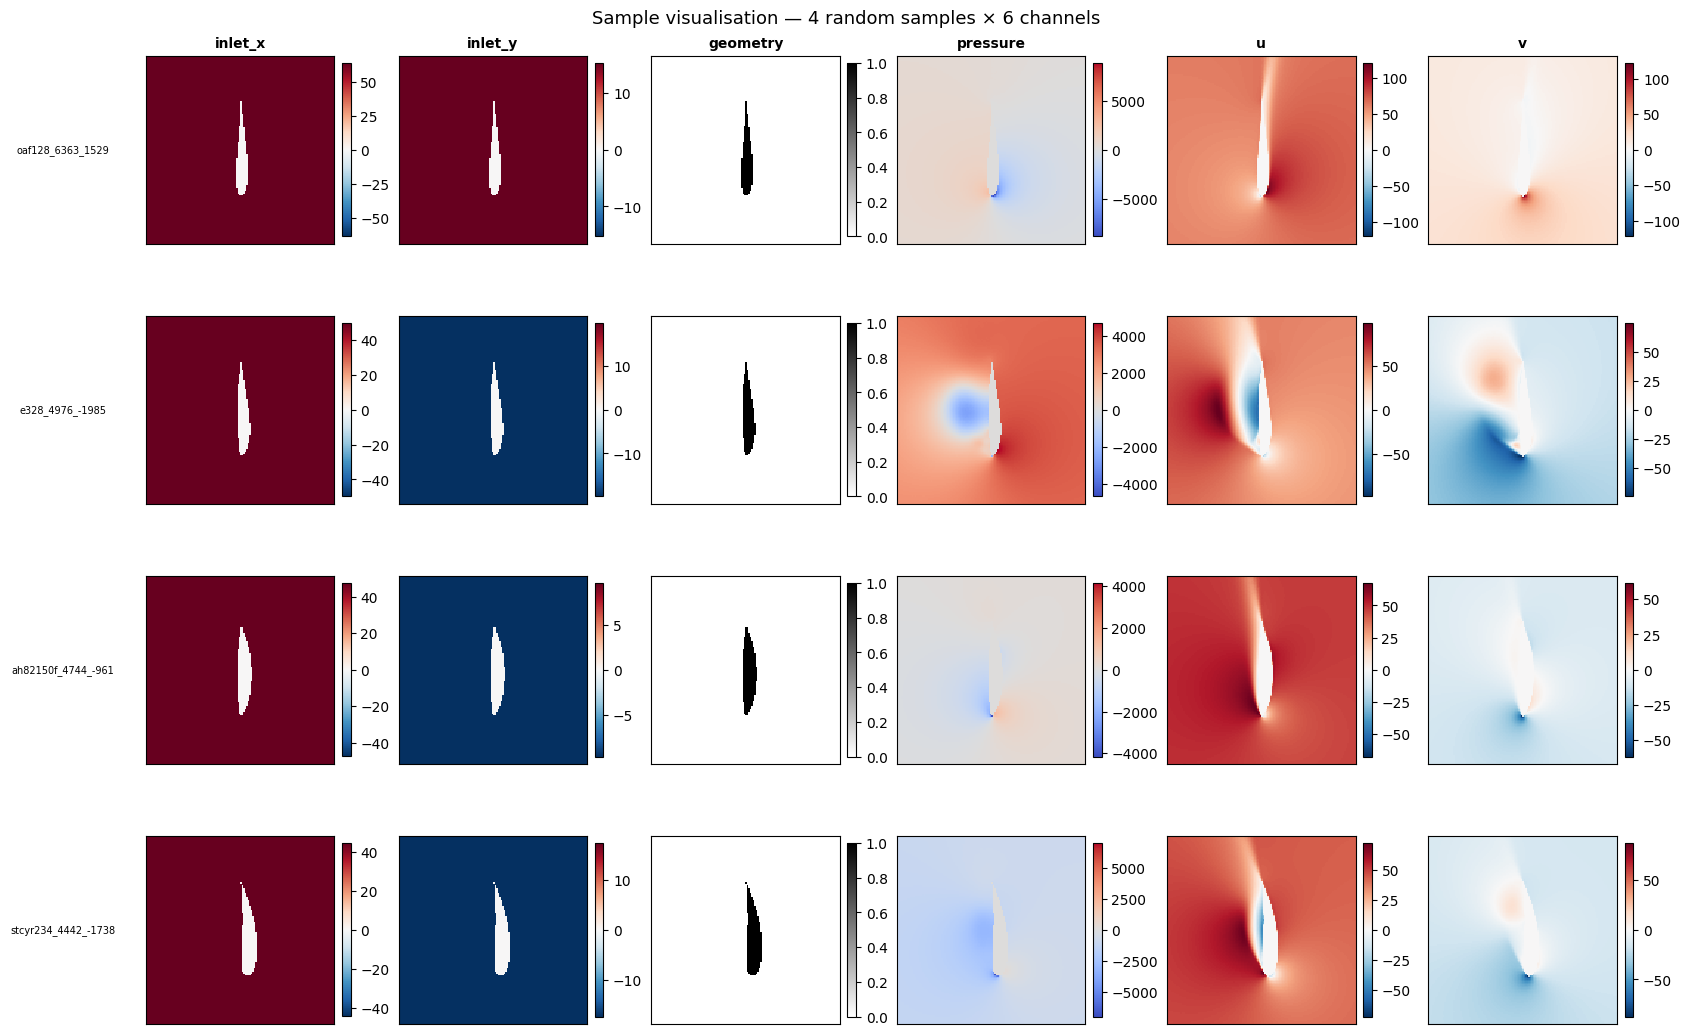

Figure saved → section2_channels.png


In [7]:
N_ROWS  = 4          # number of random samples to visualise
N_COLS  = 6          # one column per channel
CMAPS   = ["RdBu_r", "RdBu_r", "binary", "coolwarm", "RdBu_r", "RdBu_r"]

chosen = random.sample(npz_files, min(N_ROWS, len(npz_files)))

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 2.8, N_ROWS * 2.6),
    constrained_layout=True,
)
fig.suptitle("Sample visualisation — 4 random samples × 6 channels", fontsize=13, y=1.01)

for row_idx, fp in enumerate(chosen):
    data = np.load(fp)["a"]          # (6, 128, 128)
    fname = os.path.splitext(os.path.basename(fp))[0]

    for col_idx, ch_name in enumerate(ALL_CHANNELS):
        ax  = axes[row_idx][col_idx]
        ch  = data[col_idx]          # (128, 128)
        cmap = CMAPS[col_idx]

        # centre diverging colourmaps at zero for velocity/pressure
        vmax = np.abs(ch).max() if np.abs(ch).max() > 0 else 1.0
        vmin = -vmax if cmap != "binary" else 0.0
        vmax =  vmax if cmap != "binary" else 1.0

        im = ax.imshow(
            ch, origin="lower", cmap=cmap,
            vmin=vmin, vmax=vmax, interpolation="nearest"
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if row_idx == 0:
            ax.set_title(ch_name, fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(fname, fontsize=7, rotation=0, labelpad=60, va="center")
        ax.set_xticks([])
        ax.set_yticks([])

plt.savefig(os.path.join(ROOT, "section2_channels.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → section2_channels.png")

---
## Section 3 — Normalisation Statistics

Computes **per-channel mean and std** over the entire set of files and saves them as
`norm_stats.npy`.  The stats are used by `AirfoilDataset` in Section 4 so training and
inference apply identical normalisation.

```
norm_stats keys
  'input_mean'  shape (3,)  — mean  of channels [inlet_x, inlet_y, geometry]
  'input_std'   shape (3,)  — std   of channels [inlet_x, inlet_y, geometry]
  'output_mean' shape (3,)  — mean  of channels [pressure, u, v]
  'output_std'  shape (3,)  — std   of channels [pressure, u, v]
```

In [8]:
# ── 3a. accumulate moments with Welford online algorithm (memory-efficient) ───
# We avoid loading all data at once by computing running mean / M2 per channel.

N_IN  = 3   # input  channels
N_OUT = 3   # output channels

# Welford state: count, mean, M2
count = np.zeros(6)
mean  = np.zeros(6)
M2    = np.zeros(6)

for fp in tqdm(npz_files, desc="Computing norm stats"):
    arr = np.load(fp)["a"].astype(np.float64)    # (6, 128, 128)
    for c in range(6):
        pixels = arr[c].ravel()                   # 128*128 values
        for x in pixels:
            count[c] += 1
            delta      = x - mean[c]
            mean[c]   += delta / count[c]
            M2[c]     += delta * (x - mean[c])

# For large datasets the pixel-wise Welford loop above is slow.
# Re-do with vectorised batch Welford instead:
count = np.zeros(6)
mean  = np.zeros(6)
M2    = np.zeros(6)

for fp in tqdm(npz_files, desc="Computing norm stats (vectorised)"):
    arr   = np.load(fp)["a"].astype(np.float64)   # (6, 128, 128)
    batch = arr.reshape(6, -1)                     # (6, 128*128)
    n_b   = batch.shape[1]
    mean_b= batch.mean(axis=1)                     # (6,)
    var_b = batch.var(axis=1)                      # (6,)

    # parallel / Chan's algorithm for combining statistics
    n_a   = count.copy()
    delta  = mean_b - mean
    new_n  = n_a + n_b
    # avoid division by zero on first file
    safe_n = np.where(new_n > 0, new_n, 1)
    mean   = (n_a * mean + n_b * mean_b) / safe_n
    M2    += var_b * n_b + delta**2 * (n_a * n_b / safe_n)
    count  = new_n

std = np.sqrt(M2 / np.maximum(count, 1))
# guard against zero std (e.g. constant mask channel)
std = np.where(std < 1e-8, 1.0, std)

# geometry channel is binary (0/1); z-score maps its '1's to ~10σ,
# causing huge input activations. Keep it in its natural 0/1 range.
input_mean_f = mean[:3].copy().astype(np.float32)
input_std_f  = std[:3].copy().astype(np.float32)
input_mean_f[2] = 0.0   # geometry: no offset removal
input_std_f[2]  = 1.0   # geometry: no scaling (stays as 0/1 binary)

norm_stats = {
    "input_mean" : input_mean_f,
    "input_std"  : input_std_f,
    "output_mean": mean[3:].astype(np.float32),
    "output_std" : std[3:].astype(np.float32),
}

NORM_STATS_PATH = os.path.join(ROOT, "norm_stats.npy")
np.save(NORM_STATS_PATH, norm_stats)
print(f"Saved norm stats → {NORM_STATS_PATH}")

print()
print(f"{'Channel':<12} {'Mean':>12} {'Std':>12}")
print("-" * 38)
for i, name in enumerate(ALL_CHANNELS):
    grp   = "input" if i < 3 else "output"
    idx   = i if i < 3 else i - 3
    m_val = norm_stats[f"{grp}_mean"][idx]
    s_val = norm_stats[f"{grp}_std"][idx]
    print(f"{name:<12} {m_val:>12.4f} {s_val:>12.4f}")

Computing norm stats (vectorised): 100%|██████████| 6400/6400 [00:12<00:00, 521.66it/s]

Saved norm stats → /Users/idhantsingh/Desktop/aerofno/norm_stats.npy

Channel              Mean          Std
--------------------------------------
inlet_x           52.2352      26.0881
inlet_y            0.1802      13.3025
geometry           0.0000       1.0000
pressure          59.2200    1675.3601
u                 51.2259      29.0284
v                  0.1436      15.1106


---
## Section 4 — PyTorch Dataset Class

`AirfoilDataset` is the reusable dataset class for all future stages.

| Argument | Description |
|---|---|
| `data_dir` | folder containing `.npz` files |
| `split` | `'train'` or `'val'` |
| `val_ratio` | fraction held out for validation (default `0.2`) |
| `norm_stats` | dict from `norm_stats.npy`; if `None` no normalisation is applied |

In [9]:
class AirfoilDataset(Dataset):
    """
    PyTorch Dataset for the Deep-Flow-Prediction airfoil CFD dataset.

    Each .npz file contains a single simulation stored under key 'a'
    with shape (6, 128, 128):
        inputs  → channels 0-2  : [inlet_x, inlet_y, geometry]
        outputs → channels 3-5  : [pressure, u, v]

    Parameters
    ----------
    data_dir   : str  — directory containing .npz files (searched recursively)
    split      : str  — 'train' or 'val'
    val_ratio  : float — fraction of files reserved for validation
    norm_stats : dict | None — normalisation statistics (from norm_stats.npy)
    """

    def __init__(
        self,
        data_dir: str,
        split: str = "train",
        val_ratio: float = 0.2,
        norm_stats: dict = None,
    ):
        assert split in ("train", "val"), "split must be 'train' or 'val'"
        self.data_dir   = data_dir
        self.split      = split
        self.norm_stats = norm_stats

        # --- collect all .npz files (sorted for reproducibility) ----------
        all_files = sorted(
            glob.glob(os.path.join(data_dir, "**", "*.npz"), recursive=True)
        )
        if not all_files:
            raise FileNotFoundError(f"No .npz files found under: {data_dir}")

        # --- deterministic train / val split ------------------------------
        n_total = len(all_files)
        n_val   = max(1, int(n_total * val_ratio))
        n_train = n_total - n_val

        if split == "train":
            self.files = all_files[:n_train]
        else:
            self.files = all_files[n_train:]

        # --- unpack normalisation stats -----------------------------------
        if norm_stats is not None:
            self._in_mean  = torch.tensor(norm_stats["input_mean"],  dtype=torch.float32)  # (3,)
            self._in_std   = torch.tensor(norm_stats["input_std"],   dtype=torch.float32)  # (3,)
            self._out_mean = torch.tensor(norm_stats["output_mean"], dtype=torch.float32)  # (3,)
            self._out_std  = torch.tensor(norm_stats["output_std"],  dtype=torch.float32)  # (3,)
        else:
            self._in_mean = self._in_std = self._out_mean = self._out_std = None

    # ------------------------------------------------------------------
    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        arr = np.load(self.files[idx])["a"].astype(np.float32)  # (6, 128, 128)

        inp = torch.from_numpy(arr[:3])   # (3, 128, 128)  inputs
        out = torch.from_numpy(arr[3:])   # (3, 128, 128)  outputs

        # --- per-channel z-score normalisation ---------------------------
        if self.norm_stats is not None:
            # reshape stats to (3,1,1) for broadcast over spatial dims
            inp = (inp - self._in_mean[:, None, None])  / self._in_std[:, None, None]
            out = (out - self._out_mean[:, None, None]) / self._out_std[:, None, None]

        return inp, out

    # ------------------------------------------------------------------
    def denormalise_output(self, out_norm: torch.Tensor) -> torch.Tensor:
        """Reverse output normalisation (useful for inference / visualisation)."""
        if self.norm_stats is None:
            return out_norm
        return out_norm * self._out_std[:, None, None] + self._out_mean[:, None, None]


# ── quick smoke-test ──────────────────────────────────────────────────────────
stats = np.load(NORM_STATS_PATH, allow_pickle=True).item()

train_ds = AirfoilDataset(DATA_DIR, split="train", val_ratio=0.2, norm_stats=stats)
val_ds   = AirfoilDataset(DATA_DIR, split="val",   val_ratio=0.2, norm_stats=stats)

print(f"Train samples : {len(train_ds)}")
print(f"Val   samples : {len(val_ds)}")

x, y = train_ds[0]
print(f"\nSingle sample shapes — input: {tuple(x.shape)}, output: {tuple(y.shape)}")
print(f"Input  dtype  : {x.dtype}")
print(f"Output dtype  : {y.dtype}")
print(f"Input  range  : [{x.min():.3f}, {x.max():.3f}]")
print(f"Output range  : [{y.min():.3f}, {y.max():.3f}]")

Train samples : 5120
Val   samples : 1280

Single sample shapes — input: (3, 128, 128), output: (3, 128, 128)
Input  dtype  : torch.float32
Output dtype  : torch.float32
Input  range  : [-2.002, 1.000]
Output range  : [-1.765, 1.913]


---
## Section 5 — DataLoader Test

Creates `DataLoader` objects for train and val splits with `batch_size=8` and prints one
batch shape to confirm the whole data pipeline is wired up correctly.

In [10]:
BATCH_SIZE  = 8
NUM_WORKERS = 0   # 0 is safest across all platforms (MPS, Colab, Kaggle)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),   # only beneficial for CUDA
    drop_last=True,                        # keeps batch sizes uniform
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# grab one batch and print shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Train loader — input batch : {tuple(x_batch.shape)}")
print(f"Train loader — output batch: {tuple(y_batch.shape)}")

x_val, y_val = next(iter(val_loader))
print(f"Val   loader — input batch : {tuple(x_val.shape)}")
print(f"Val   loader — output batch: {tuple(y_val.shape)}")

print()
print(f"Batches per epoch (train) : {len(train_loader)}")
print(f"Batches per epoch (val)   : {len(val_loader)}")

Train loader — input batch : (8, 3, 128, 128)
Train loader — output batch: (8, 3, 128, 128)
Val   loader — input batch : (8, 3, 128, 128)
Val   loader — output batch: (8, 3, 128, 128)

Batches per epoch (train) : 640
Batches per epoch (val)   : 160


---
## Section 6 — Overfit Sanity Check

A minimal **3-layer CNN** (no skip connections, no FNO) is trained on a **single batch of 8
samples** for 500 epochs.  A well-functioning pipeline should drive MSE loss below 0.01.

This check validates:
* data loading ✓
* normalisation ✓
* device tensors ✓
* gradient flow ✓
* optimiser step ✓

In [11]:
# ── 6a. define the mini CNN with positional encoding ─────────────────

# Build 2D positional encoding channels once (shape: 1, 2, H, W).
# Adding (x_coord, y_coord) in [-1, 1] to each pixel's features gives the
# network a unique spatial identity, so it can distinguish different pixels
# even in the exterior region where all flow channels are constant.
_H, _W = 128, 128
_xc = torch.linspace(-1, 1, _W, device=device).view(1, _W).expand(_H, _W)   # (H,W)
_yc = torch.linspace(-1, 1, _H, device=device).view(_H, 1).expand(_H, _W)   # (H,W)
POS_ENC = torch.stack([_xc, _yc], dim=0).unsqueeze(0)                        # (1,2,H,W)


class MiniCNN(nn.Module):
    """
    Lightweight 3-layer CNN for pipeline validation only.

    Takes (B, 3, H, W) flow input + (B, 2, H, W) positional channels that
    are appended internally, giving 5 input channels total.  The positional
    channels give each pixel a unique spatial identity so the network can
    memorise spatially-varying fields from only 3 conv layers.

    Input : (B, 3, 128, 128)   [inlet_x, inlet_y, geometry]
    Output: (B, 3, 128, 128)   [pressure, u, v]
    """

    def __init__(self, n_in: int = 3, n_out: int = 3, width: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            # layer 1: 5 channels in (3 flow + 2 pos)
            nn.Conv2d(n_in + 2, width, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            # layer 2
            nn.Conv2d(width,    width, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            # layer 3
            nn.Conv2d(width,    n_out, kernel_size=3, padding=1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]
        pos = POS_ENC.expand(B, -1, -1, -1)   # broadcast to batch
        return self.conv(torch.cat([x, pos], dim=1))


model = MiniCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"MiniCNN parameter count: {total_params:,}")


MiniCNN parameter count: 41,603


In [14]:
# ── 6b. overfit one batch for 200 epochs ─────────────────────────────────────
OVERFIT_EPOCHS = 500
CONVERGE_THRESH = 0.01

# pin the single batch to the target device
x_fixed = x_batch.to(device)   # (8, 3, 128, 128)
y_fixed = y_batch.to(device)   # (8, 3, 128, 128)

criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=2e-3)
# cosine annealing decays lr to 1e-5, helping convergence in fixed epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=OVERFIT_EPOCHS, eta_min=1e-5
)

loss_history = []

for epoch in tqdm(range(1, OVERFIT_EPOCHS + 1), desc="Overfitting single batch"):
    model.train()
    optimiser.zero_grad()
    pred = model(x_fixed)
    loss = criterion(pred, y_fixed)
    loss.backward()
    optimiser.step()
    scheduler.step()
    loss_history.append(loss.item())

final_loss = loss_history[-1]
print(f"\nEpoch {OVERFIT_EPOCHS:>3d} — loss: {final_loss:.6f}")

if final_loss < CONVERGE_THRESH:
    print(f"✓ Converged below {CONVERGE_THRESH} — pipeline is healthy.")
else:
    print(
        f"⚠ WARNING: loss {final_loss:.6f} did NOT drop below {CONVERGE_THRESH}.\n"
        "  Check data normalisation, learning rate, or number of epochs."
    )

Overfitting single batch: 100%|██████████| 500/500 [00:08<00:00, 59.52it/s]


Epoch 500 — loss: 0.004653
✓ Converged below 0.01 — pipeline is healthy.


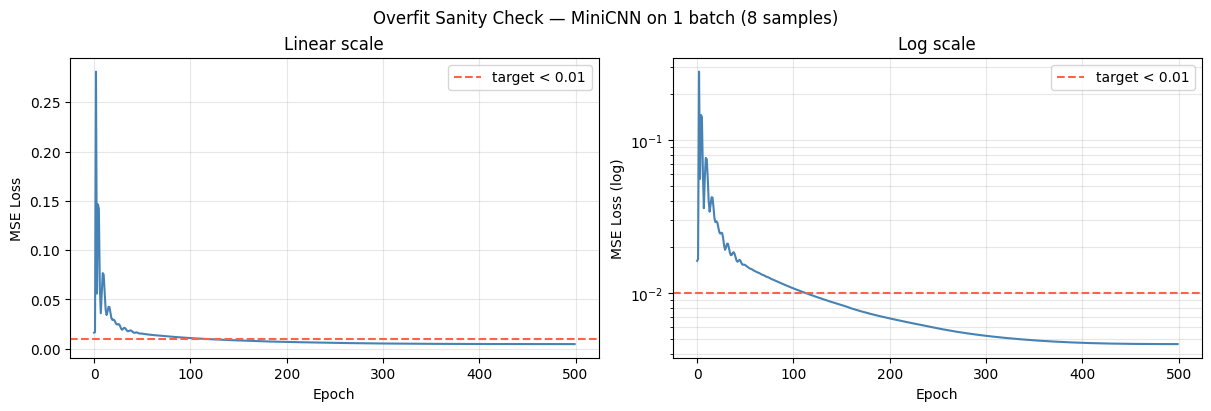

Figure saved → section6_overfit_loss.png

Final loss : 0.004653  |  Converged: True


In [15]:
# ── 6c. plot the training loss curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig.suptitle("Overfit Sanity Check — MiniCNN on 1 batch (8 samples)", fontsize=12)

# linear scale
axes[0].plot(loss_history, color="steelblue", linewidth=1.5)
axes[0].axhline(CONVERGE_THRESH, color="tomato", linestyle="--", label=f"target < {CONVERGE_THRESH}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Linear scale")
axes[0].legend()
axes[0].grid(alpha=0.3)

# log scale
axes[1].semilogy(loss_history, color="steelblue", linewidth=1.5)
axes[1].axhline(CONVERGE_THRESH, color="tomato", linestyle="--", label=f"target < {CONVERGE_THRESH}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss (log)")
axes[1].set_title("Log scale")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

plt.savefig(os.path.join(ROOT, "section6_overfit_loss.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved → section6_overfit_loss.png")
print(f"\nFinal loss : {final_loss:.6f}  |  Converged: {final_loss < CONVERGE_THRESH}")